Base carregada: (1470, 35)

Cargos classificados:
                    CARGO TIPO_CARGO
Healthcare Representative      Saúde
          Human Resources         RH
    Laboratory Technician    Técnico
                  Manager  Liderança
   Manufacturing Director  Liderança
        Research Director  Liderança
       Research Scientist   Pesquisa
          Sales Executive  Comercial
     Sales Representative  Comercial

Fonte API: 1470 | Implantação: 5 | Total: 1475

📊 Funcionários por departamento
              DEPARTAMENTO  TOTAL  DESLIGAMENTOS  TAXA_PCT
Pesquisa e Desenvolvimento    963            134      13.9
                    Vendas    448             92      20.5
          Recursos Humanos     64             12      18.8

📊 Desligamentos por tipo de cargo
TIPO_CARGO  TOTAL  DESLIGAMENTOS  TAXA_PCT
   Técnico    260             63      24.2
        RH     53             12      22.6
 Comercial    410             90      22.0
  Pesquisa    292             47      16.1
     Saúde   

/tmp/ipykernel_521/2282168687.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='importancia', y='variavel', palette='Blues_r')


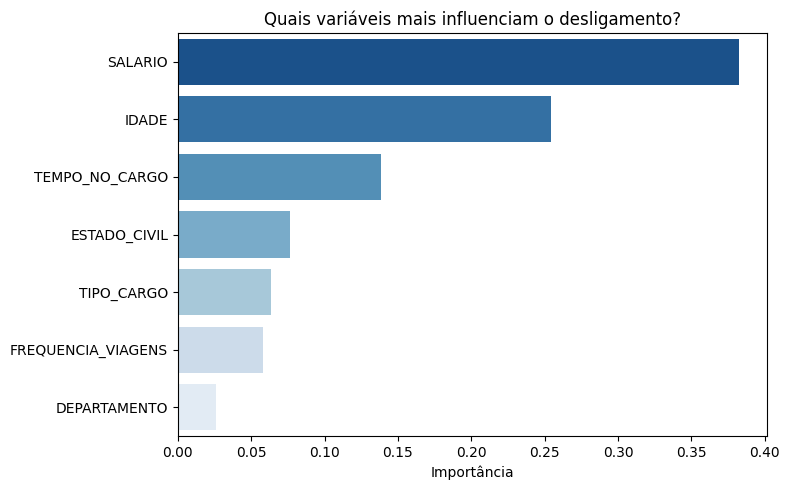

          variavel  importancia
           SALARIO     0.382549
             IDADE     0.254536
    TEMPO_NO_CARGO     0.138638
      ESTADO_CIVIL     0.076520
        TIPO_CARGO     0.063604
FREQUENCIA_VIAGENS     0.058320
      DEPARTAMENTO     0.025833
              IDADE  DESLIGADO
ESTADO_CIVIL                  
Casado        37.76       0.12
Divorciado    37.50       0.10
Solteiro      35.31       0.26
           SALARIO  IDADE  TEMPO_NO_CARGO
DESLIGADO                                
0          6835.30  37.56            4.48
1          4780.42  33.60            2.90


In [13]:
import pandas as pd
import sqlite3

# ── EXTRAÇÃO ──────────────────────────────────────────────────────
df = pd.read_csv('BaseIBM.csv')
print(f"Base carregada: {df.shape}")

# ── SELEÇÃO E RENOMEAÇÃO ──────────────────────────────────────────
colunas_desejadas = [
    'EmployeeNumber', 'JobRole', 'Department', 'MonthlyIncome',
    'YearsInCurrentRole', 'PerformanceRating', 'Attrition',
    'BusinessTravel', 'Gender', 'Age', 'MaritalStatus', 'EducationField'
]
df_selecionado = df[colunas_desejadas].copy()
df_selecionado = df_selecionado.rename(columns={
    'EmployeeNumber':    'EMPLOYEE_ID',
    'JobRole':           'CARGO',
    'Department':        'DEPARTAMENTO',
    'MonthlyIncome':     'SALARIO',
    'YearsInCurrentRole':'TEMPO_NO_CARGO',
    'PerformanceRating': 'NOTA_PERFORMANCE',
    'Attrition':         'DESLIGADO',
    'BusinessTravel':    'FREQUENCIA_VIAGENS',
    'Gender':            'GENERO',
    'Age':               'IDADE',
    'MaritalStatus':     'ESTADO_CIVIL',
    'EducationField':    'ESCOLARIDADE'
})

# ── NORMALIZAÇÃO ──────────────────────────────────────────────────
df_selecionado['DESLIGADO'] = df_selecionado['DESLIGADO'].map({'Yes': 1, 'No': 0})

df_selecionado['NOTA_PERFORMANCE'] = df_selecionado['NOTA_PERFORMANCE'].map({
    1: 'Abaixo do esperado',
    2: 'Atende parcialmente',
    3: 'Dentro do esperado',
    4: 'Acima do esperado'
})

df_selecionado['DEPARTAMENTO'] = df_selecionado['DEPARTAMENTO'].map({
    'Sales':                  'Vendas',
    'Research & Development': 'Pesquisa e Desenvolvimento',
    'Human Resources':        'Recursos Humanos'
})

df_selecionado['FREQUENCIA_VIAGENS'] = df_selecionado['FREQUENCIA_VIAGENS'].map({
    'Travel_Rarely':     'Viaja Raramente',
    'Travel_Frequently': 'Viaja Frequentemente',
    'Non-Travel':        'Não Viaja'
})

df_selecionado['GENERO'] = df_selecionado['GENERO'].map({
    'Male': 'Masculino', 'Female': 'Feminino'
})

df_selecionado['ESTADO_CIVIL'] = df_selecionado['ESTADO_CIVIL'].map({
    'Single': 'Solteiro', 'Married': 'Casado', 'Divorced': 'Divorciado'
})

df_selecionado['FAIXA_ETARIA'] = pd.cut(df_selecionado['IDADE'],
    bins=[17, 25, 35, 45, 100],
    labels=['18-25', '26-35', '36-45', '45+']).astype(str)

df_selecionado['TEMPO_CARGO_CATEGORIA'] = pd.cut(df_selecionado['TEMPO_NO_CARGO'],
    bins=[-1, 0.5, 1, 3, 6, 1000],
    labels=['Menos de 6 meses', '6 meses a 1 ano', '1 a 3 anos', '3 a 6 anos', '6+ anos']).astype(str)

# ── LOOKUP TIPO_CARGO ─────────────────────────────────────────────
tipo_cargo_lookup = [
    {'keyword': 'manager',        'tipo': 'Liderança'},
    {'keyword': 'director',       'tipo': 'Liderança'},
    {'keyword': 'executive',      'tipo': 'Comercial'},
    {'keyword': 'sales',          'tipo': 'Comercial'},
    {'keyword': 'scientist',      'tipo': 'Pesquisa'},
    {'keyword': 'research',       'tipo': 'Pesquisa'},
    {'keyword': 'laboratory',     'tipo': 'Técnico'},
    {'keyword': 'technician',     'tipo': 'Técnico'},
    {'keyword': 'lab',            'tipo': 'Técnico'},
    {'keyword': 'hr',             'tipo': 'RH'},
    {'keyword': 'human resources','tipo': 'RH'},
    {'keyword': 'healthcare',     'tipo': 'Saúde'},
    {'keyword': 'representative', 'tipo': 'Operacional'},
    {'keyword': 'manufacturing',  'tipo': 'Operacional'},
]

def classificar_cargo(cargo):
    cargo_lower = cargo.lower()
    for item in tipo_cargo_lookup:
        if item['keyword'] in cargo_lower:
            return item['tipo']
    return 'Outros'

df_selecionado['TIPO_CARGO'] = df_selecionado['CARGO'].apply(classificar_cargo)

print("\nCargos classificados:")
print(df_selecionado[['CARGO','TIPO_CARGO']].drop_duplicates().sort_values('CARGO').to_string(index=False))

# ── FONTE 2: IMPLANTAÇÃO ──────────────────────────────────────────
df_implantacao = pd.DataFrame({
    'EMPLOYEE_ID':          [2000, 2001, 2002, 2003, 2004],
    'CARGO':                ['Sales Manager', 'HR Representative', 'Research Director', 'Lab Technician', 'Sales Executive'],
    'DEPARTAMENTO':         ['Vendas', 'Recursos Humanos', 'Pesquisa e Desenvolvimento', 'Pesquisa e Desenvolvimento', 'Vendas'],
    'SALARIO':              [8000, 4500, 12000, 3200, 6000],
    'TEMPO_NO_CARGO':       [3, 1, 8, 2, 5],
    'NOTA_PERFORMANCE':     ['Dentro do esperado', 'Acima do esperado', 'Acima do esperado', 'Dentro do esperado', 'Abaixo do esperado'],
    'DESLIGADO':            [0, 0, 0, 1, 0],
    'FREQUENCIA_VIAGENS':   ['Viaja Raramente', 'Não Viaja', 'Viaja Frequentemente', 'Viaja Raramente', 'Viaja Frequentemente'],
    'GENERO':               ['Masculino', 'Feminino', 'Masculino', 'Feminino', 'Masculino'],
    'IDADE':                [35, 28, 45, 32, 41],
    'ESTADO_CIVIL':         ['Casado', 'Solteiro', 'Casado', 'Solteiro', 'Divorciado'],
    'ESCOLARIDADE':         ['Business', 'Human Resources', 'Life Sciences', 'Technical', 'Marketing'],
    'FAIXA_ETARIA':         ['26-35', '26-35', '36-45', '26-35', '36-45'],
    'TEMPO_CARGO_CATEGORIA':['Até 3 anos', 'Até 3 anos', '6+ anos', 'Até 3 anos', '3 a 6 anos'],
    'FONTE':                ['Implantacao'] * 5
})
df_implantacao['TIPO_CARGO'] = df_implantacao['CARGO'].apply(classificar_cargo)

# ── APPEND ────────────────────────────────────────────────────────
df_selecionado['FONTE'] = 'API'

colunas_comuns = [
    'EMPLOYEE_ID', 'CARGO', 'DEPARTAMENTO', 'SALARIO', 'TEMPO_NO_CARGO',
    'NOTA_PERFORMANCE', 'DESLIGADO', 'FREQUENCIA_VIAGENS', 'GENERO',
    'IDADE', 'ESTADO_CIVIL', 'ESCOLARIDADE', 'FAIXA_ETARIA',
    'TEMPO_CARGO_CATEGORIA', 'TIPO_CARGO', 'FONTE'
]

df_fato = pd.concat([
    df_selecionado[colunas_comuns],
    df_implantacao[colunas_comuns]
], ignore_index=True)

print(f"\nFonte API: {len(df_selecionado)} | Implantação: {len(df_implantacao)} | Total: {len(df_fato)}")

# ── SQLITE + QUERIES ──────────────────────────────────────────────
conn = sqlite3.connect('rh_analytics.db')
df_fato.to_sql('FatoFuncionarios', conn, if_exists='replace', index=False)

queries = {
    "Funcionários por departamento": """
        SELECT DEPARTAMENTO, COUNT(*) as TOTAL,
               SUM(DESLIGADO) as DESLIGAMENTOS,
               ROUND(AVG(DESLIGADO)*100,1) as TAXA_PCT
        FROM FatoFuncionarios GROUP BY DEPARTAMENTO ORDER BY TOTAL DESC
    """,
    "Desligamentos por tipo de cargo": """
        SELECT TIPO_CARGO, COUNT(*) as TOTAL,
               SUM(DESLIGADO) as DESLIGAMENTOS,
               ROUND(AVG(DESLIGADO)*100,1) as TAXA_PCT
        FROM FatoFuncionarios GROUP BY TIPO_CARGO ORDER BY TAXA_PCT DESC
    """,
    "Distribuição por faixa etária": """
        SELECT FAIXA_ETARIA, COUNT(*) as TOTAL,
               ROUND(AVG(SALARIO),0) as SALARIO_MEDIO,
               ROUND(AVG(DESLIGADO)*100,1) as TAXA_DESLIGAMENTO_PCT
        FROM FatoFuncionarios GROUP BY FAIXA_ETARIA ORDER BY FAIXA_ETARIA
    """,
    "Tempo no cargo vs desligamento": """
        SELECT TEMPO_CARGO_CATEGORIA, COUNT(*) as TOTAL,
               ROUND(AVG(DESLIGADO)*100,1) as TAXA_PCT,
               ROUND(AVG(SALARIO),0) as SALARIO_MEDIO
        FROM FatoFuncionarios GROUP BY TEMPO_CARGO_CATEGORIA ORDER BY TAXA_PCT DESC
    """,
    "Elegibilidade para promoção (mínimo 6 meses no cargo)": """
    SELECT CASE WHEN TEMPO_NO_CARGO >= 0.5 THEN 'Elegível' ELSE 'Inelegível' END as ELEGIBILIDADE,
           COUNT(*) as TOTAL,
           ROUND(AVG(SALARIO),0) as SALARIO_MEDIO,
           ROUND(AVG(DESLIGADO)*100,1) as TAXA_DESLIGAMENTO_PCT
    FROM FatoFuncionarios GROUP BY ELEGIBILIDADE
"""
}

for titulo, query in queries.items():
    print(f"\n{'='*55}\n📊 {titulo}\n{'='*55}")
    print(pd.read_sql(query, conn).to_string(index=False))

conn.close()
print("\n✅ Pipeline completo! Dados salvos em rh_analytics.db")

# ── EXPORTA CSV FINAL ─────────────────────────────────────────────
df_fato.to_csv('FatoFuncionarios.csv', index=False)
print("✅ CSV exportado: FatoFuncionarios.csv")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# ── PREPARA OS DADOS PRA MODELAGEM ───────────────────────────────
# Usa só a fonte API (dados reais, maior volume)
df_model = df_fato[df_fato['FONTE'] == 'API'].copy()

# Seleciona variáveis preditoras
features = ['SALARIO', 'TEMPO_NO_CARGO', 'IDADE', 'TIPO_CARGO',
            'DEPARTAMENTO', 'FREQUENCIA_VIAGENS', 'ESTADO_CIVIL']

df_model = df_model[features + ['DESLIGADO']].dropna()

# Codifica variáveis categóricas (texto -> número)
le = LabelEncoder()
for col in ['TIPO_CARGO', 'DEPARTAMENTO', 'FREQUENCIA_VIAGENS', 'ESTADO_CIVIL']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# ── TREINA O MODELO ───────────────────────────────────────────────
X = df_model[features]
y = df_model['DESLIGADO']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# ── AVALIA O MODELO ───────────────────────────────────────────────
y_pred = modelo.predict(X_test)
print("📊 Relatório de Classificação:")
print(classification_report(y_test, y_pred))

# ── IMPORTÂNCIA DAS VARIÁVEIS ─────────────────────────────────────
importancias = pd.DataFrame({
    'variavel': features,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancias, x='importancia', y='variavel', palette='Blues_r')
plt.title('Quais variáveis mais influenciam o desligamento?')
plt.xlabel('Importância')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))

## HIPOTESE ESTADO CIVIL
print(df_fato.groupby('ESTADO_CIVIL')[['IDADE', 'DESLIGADO']].mean().round(2))

## HIPOTESE MEDIA SALARIAL
print(df_fato.groupby('DESLIGADO')[['SALARIO', 'IDADE', 'TEMPO_NO_CARGO']].mean().round(2))